# Non-negative matrix factorization of a ZrCuAl mixed-phase dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

import time

from sklearn.decomposition import PCA

import ncempy.io as nio

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, SymLogNorm

import string
import matplotlib.patheffects as patheffects

In [3]:
letters = list(string.ascii_lowercase)

In [4]:
"""
functional (R)NMF, based on 
- sklearn NMF (CD) function
- RNMF code (ristretto)

Aimed at directly comparing NMF and RNMF. Not for production. 
- no convergence, just pass number of iterations
- different initialization
- only CD (!)
- option to calculate loss (and return violation) for every iteration which would otherwise be a bit of a waste.
- remove regularization options

the ristretto package: https://github.com/erichson/ristretto

any work using this code should cite the relevant paper  https://arxiv.org/abs/1608.02148

this package offers more functionality besides NMF, but only the necessary imports/dependencies were moved here.
"""

# imports: thrown together
from math import log, sqrt
from functools import partial
import numpy as np

from sklearn.utils import check_random_state
from sklearn.decomposition._nmf import _initialize_nmf, _beta_divergence
from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast

from scipy import fftpack, linalg, sparse
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import safe_sparse_dot

# from sketches
def random_axis_sample(A, l, axis, random_state):
    """randomly sample the index of axis"""
    return random_state.choice(A.shape[axis], size=l, replace=False)


def random_gaussian_map(A, l, axis, random_state):
    """generate random gaussian map"""
    return random_state.standard_normal(size=(A.shape[axis], l)).astype(A.dtype)


def random_uniform_map(A, l, axis, random_state):
    """generate random uniform map"""
    return random_state.uniform(-1, 1, size=(A.shape[axis], l)).astype(A.dtype)


def sparse_random_map(A, l, axis, density, random_state):
    """generate sparse random sampling"""
    # TODO: evaluete random_state paramter: we want to pass it to sparse.random
    #       most definitely to sparsely sample the nnz elements of Omega, but
    #       is using random_state in data_rvs redundant?
    values = (-sqrt(1. / density), sqrt(1. / density))
    data_rvs = partial(random_state.choice, values)

    return sparse.random(A.shape[axis], l, density=density, data_rvs=data_rvs,
                         random_state=random_state, dtype=A.dtype)

# from transforms
def johnson_lindenstrauss(A, l, axis=1, random_state=None):
    """

    Given an m x n matrix A, and an integer l, this scheme computes an m x l
    orthonormal matrix Q whose range approximates the range of A

    """
    random_state = check_random_state(random_state)

    A = np.asarray(A)
    if A.ndim != 2:
        raise ValueError('A must be a 2D array, not %dD' % A.ndim)

    if axis not in (0, 1):
        raise ValueError('If supplied, axis must be in (0, 1)')

    # construct gaussian random matrix
    Omega = random_gaussian_map(A, l, axis, random_state)

    # project A onto Omega
    if axis == 0:
        return Omega.T.dot(A)
    return A.dot(Omega)


def sparse_johnson_lindenstrauss(A, l, density=None, axis=1, random_state=None):
    """

    Given an m x n matrix A, and an integer l, this scheme computes an m x l
    orthonormal matrix Q whose range approximates the range of A

    Parameters
    ----------
    density : sparse matrix density

    """
    random_state = check_random_state(random_state)

    A = np.asarray(A)
    if A.ndim != 2:
        raise ValueError('A must be a 2D array, not %dD' % A.ndim)

    if axis not in (0, 1):
        raise ValueError('If supplied, axis must be in (0, 1)')

    if density is None:
        density = log(A.shape[0]) / A.shape[0]

    # construct sparse sketch
    Omega = sparse_random_map(A, l, axis, density, random_state)

    # project A onto Omega
    if axis == 0:
        return safe_sparse_dot(Omega.T, A)
    return safe_sparse_dot(A, Omega)

# from sketch.utils
def orthonormalize(A, overwrite_a=True, check_finite=False):
    """orthonormalize the columns of A via QR decomposition"""
    # NOTE: for A(m, n) 'economic' returns Q(m, k), R(k, n) where k is min(m, n)
    # TODO: when does overwrite_a even work? (fortran?)
    Q, _ = linalg.qr(A, overwrite_a=overwrite_a, check_finite=check_finite,
                     mode='economic', pivoting=False)
    return Q


def perform_subspace_iterations(A, Q, n_iter=2, axis=1):
    """perform subspace iterations on Q"""
    # TODO: can we figure out how not to transpose for row wise
    if axis == 0:
        Q = Q.T

    # orthonormalize Y, overwriting
    Q = orthonormalize(Q)

    # perform subspace iterations
    for _ in range(n_iter):
        if axis == 0:
            Z = orthonormalize(A.dot(Q))
            Q = orthonormalize(A.T.dot(Z))
        else:
            Z = orthonormalize(A.T.dot(Q))
            Q = orthonormalize(A.dot(Z))

    if axis == 0:
        return Q.T
    return Q


# from utils
def conjugate_transpose(A):
    """Performs conjugate transpose of A"""
    if A.dtype == np.complexfloating:
        return A.conj().T
    return A.T

# from qb.py
def _compute_rqb(A, rank, oversample, n_subspace, sparse, random_state):
    if sparse:
        Q = sparse_johnson_lindenstrauss(A, rank + oversample,
                                         random_state=random_state)
    else:
        Q = johnson_lindenstrauss(A, rank + oversample, random_state=random_state)

    if n_subspace > 0:
        Q = perform_subspace_iterations(A, Q, n_iter=n_subspace, axis=1)
    else:
        Q = orthonormalize(Q)

    # Project the data matrix a into a lower dimensional subspace
    B = conjugate_transpose(Q).dot(A)

    return Q, B


def compute_rqb(A, rank, oversample=20, n_subspace=2, n_blocks=1, sparse=False,
                random_state=None):
    """Randomized QB Decomposition.

    Randomized algorithm for computing the approximate low-rank QB
    decomposition of a rectangular `(m, n)` matrix `A`, with target rank
    `rank << min{m, n}`. The input matrix is factored as `A = Q * B`.

    The quality of the approximation can be controlled via the oversampling
    parameter `oversample` and `n_subspace` which specifies the number of
    subspace iterations.

    Parameters
    ----------
    A : array_like, shape `(m, n)`.
        Input array.

    rank : integer
        Target rank. Best if `rank << min{m,n}`

    oversample : integer, optional (default: 10)
        Controls the oversampling of column space. Increasing this parameter
        may improve numerical accuracy.

    n_subspace : integer, default: 2.
        Parameter to control number of subspace iterations. Increasing this
        parameter may improve numerical accuracy. Every additional subspace
        iterations requires an additional full pass over the data matrix.

    n_blocks : integer, default: 1.
        If `n_blocks > 1` a column blocked QB decomposition procedure will be
        performed. A larger number requires less fast memory, while it
        leads to a higher computational time.

    sparse : boolean, optional (default: False)
        If sparse == True, perform compressed random qr decomposition.

    random_state : integer, RandomState instance or None, optional (default `None`)
        If integer, random_state is the seed used by the random number generator;
        If RandomState instance, random_state is the random number generator;
        If None, the random number generator is the RandomState instance used by np.random.

    Returns
    -------
    Q:  array_like, shape `(m, rank + oversample)`.
        Orthonormal basis matrix.

    B : array_like, shape `(rank + oversample, n)`.
        Smaller matrix.

    References
    ----------
    N. Halko, P. Martinsson, and J. Tropp.
    "Finding structure with randomness: probabilistic
    algorithms for constructing approximate matrix
    decompositions" (2009).
    (available at `arXiv <http://arxiv.org/abs/0909.4061>`_).

    S. Voronin and P.Martinsson.
    "RSVDPACK: Subroutines for computing partial singular value
    decompositions via randomized sampling on single core, multi core,
    and GPU architectures" (2015).
    (available at `arXiv <http://arxiv.org/abs/1502.05366>`_).
    """
    if n_blocks > 1:
        m, n = A.shape

        # index sets
        row_sets = np.array_split(range(m), n_blocks)

        Q_block = []
        K = []

        nblock = 1
        for rows in row_sets:
            # converts A to array, raise ValueError if A has inf or nan
            Qtemp, Ktemp = _compute_rqb(np.asarray_chkfinite(A[rows, :]), 
                rank=rank, oversample=oversample, n_subspace=n_subspace, 
                sparse=sparse, random_state=random_state)

            Q_block.append(Qtemp)
            K.append(Ktemp)
            nblock += 1

        Q_small, B = _compute_rqb(
            np.concatenate(K, axis=0), rank=rank, oversample=oversample,
            n_subspace=n_subspace, sparse=sparse, random_state=random_state)

        Q_small = np.vsplit(Q_small, n_blocks)

        Q = [Q_block[i].dot(Q_small[i]) for i in range(n_blocks)]
        Q = np.concatenate(Q, axis=0)

    else:
        Q, B = _compute_rqb(np.asarray_chkfinite(A), 
            rank=rank, oversample=oversample, n_subspace=n_subspace,
            sparse=sparse, random_state=random_state)

    return Q, B


# adapted by Andreas Werbrouck 
def nmf(X, rank, init='nndsvd', maxiter=200, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 #tol=1e-10, 
                 random_state=None):
    """
    Nonnegative Matrix Factorization. 
    With randomization (QB) option and loss calculation option for diagnostic/plotting purposes.
    Note that the tol parameter is murky, use maxiter to control the algorithm.
...
    """

    random_state = check_random_state(random_state)

    # converts A to array, raise ValueError if A has inf or nan
    X = np.asarray_chkfinite(X)
    X = check_array(X, accept_sparse="csr") # normal NMF
    m, n = X.shape

    flipped = False
    if n > m:
        X = X.T
        m, n = X.shape
        flipped = True

    if np.any(X < 0):
        raise ValueError("Input matrix with nonnegative elements is required.")


    #  Initialization methods for factor matrices W and H
    W, H = _initialize_nmf(X, rank, init=init, eps=1e-6, random_state=random_state)
    Ht = np.array(H.T, order='C')

    if QB_project:
        Q, B = compute_rqb(X, rank, oversample=oversample,
                        n_subspace=n_subspace, random_state=random_state)
        W_tilde = Q.T.dot(W)
    
    if calculate_loss:
        # initialize matrices for storing
        losses = []
        tols = []

    # Iterate the HALS algorithm until convergence or maxiter is reached
    # _update_cdnmf_fast edits its first argument in place, while returning the violation
    # violation is NOT the loss (another difference with MU!) 
    # but the total projection of the gradient
    violation = 0.0
    for niter in range(maxiter):

        if QB_project:
            # Update factor matrix H
            WtW = W.T.dot(W)
            BtW = B.T.dot(W_tilde)
            # compute violation update
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, BtW, permutation.astype(np.intp)) # this is where H is updated
            

            # Update factor matrix W
            HHt = Ht.T.dot(Ht)
            # Rotate AHt back to high-dimensional space
            BHt = Q.dot(B.dot(Ht))
            # compute violation update 
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, BHt, permutation.astype(np.intp)) # this is where W is updated

            # Project W to low-dimensional space
            W_tilde = Q.T.dot(W)
        else: # normal CD
            # Update H
            WtW = W.T.dot(W)
            XtW = X.T.dot(W)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, XtW, permutation.astype(np.intp))

            # Update W
            HHt = np.dot(Ht.T, Ht)
            XHt = safe_sparse_dot(X, Ht)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, XHt, permutation.astype(np.intp))

        if niter == 0:
            if violation == 0: break
            violation_init = violation

        # if violation / violation_init <= tol:
        #     break # this should not be a stopping condition in our case

        if calculate_loss:
            if flipped:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True) # unsure about this
            else:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)

            losses.append(loss)
            tols.append(violation / violation_init)

    # Return factor matrices
    if calculate_loss:
        if flipped:
            return(Ht, W.T, np.array(losses), np.array(tols))
        return(W, Ht.T, np.array(losses), np.array(tols))
    
    
    if flipped:
        return(Ht, W.T)
    return(W, Ht.T)

In [5]:
# Read the DM4 file
meas = nio.read('data/ZrCuAl.dm4')
X = meas['data']  # This is the numpy array

x_real, y_real, x_reci, y_reci = X.shape

Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])

print(x_real, y_real, x_reci, y_reci)

36 36 128 128


## Part 1: PCA

In [6]:
# PCA - new
k = 20
pca_20 = PCA(n_components = k)
W_pca_20 = pca_20.fit_transform(Xf)
H_pca_20 = pca_20.components_

NameError: name 'pca' is not defined

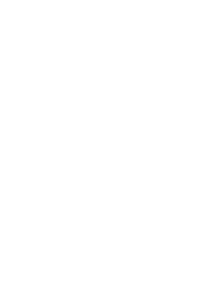

In [7]:
plt.figure(figsize=(2,3))
plt.plot(np.arange(k) + 1, pca.explained_variance_ratio_, '.')
# plt.plot(np.arange(k + 1), 0.002*np.ones(k+1), 'k:')
plt.ylabel('Explained variance ratio')
plt.xlabel('Components')
plt.yscale('log')
plt.ylim([1e-3, 1])
plt.tight_layout()
plt.gca().text(0.04, 0.97, letters[0] + ')', transform=plt.gca().transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
plt.savefig('figures/ZrCuAl_EVR.png', dpi=300)

In [ ]:
def add_cbar(fig1, ax1, im1, ticks=None):
    divider = make_axes_locatable(ax1)
    cax1 = divider.append_axes('right', size='5%', pad=0.05)
    clb = fig1.colorbar(im1, cax=cax1, orientation='vertical')

    if ticks is not None:
        clb.set_ticks(ticks)
        def format_scientific(x):
            if x == 0: return '0'
            sign = '-' if x < 0 else ''
            # Get exponent
            import math
            exponent = int(math.floor(math.log10(abs(x))))
            return f'{sign}$10^{{{exponent}}}$'
            
        labels = [format_scientific(t) for t in ticks]
        clb.set_ticklabels(labels)

LOSS:  3592.3552


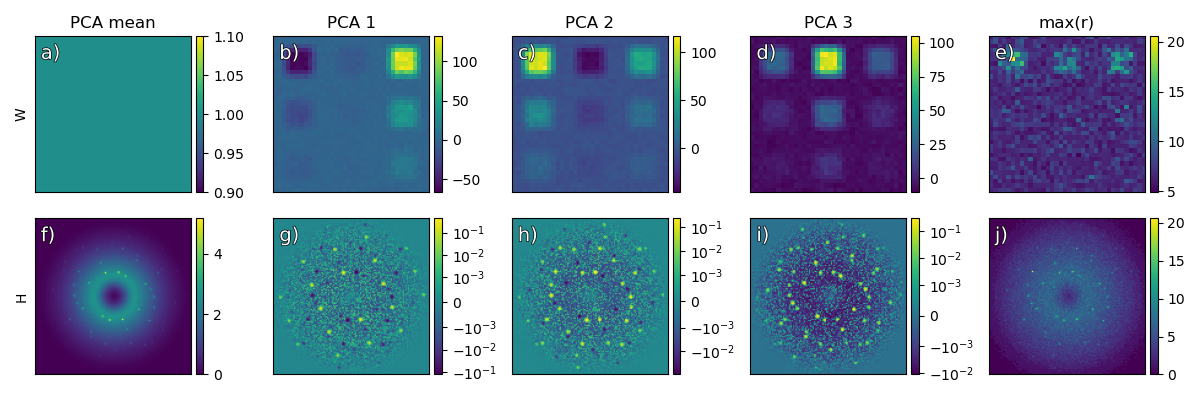

In [ ]:
# pca with 3 components.
k_PCA = 3
pca = PCA(n_components = k_PCA)
W_PCA = pca.fit_transform(Xf)
H_PCA = pca.components_

# calculate residuals
r_PCA = np.abs(Xf - pca.mean_ - np.dot(W_PCA, H_PCA))

res_comp_PCA = np.max(r_PCA, axis=0).reshape((x_reci, y_reci))
res_map_PCA = np.max(r_PCA, axis=1).reshape((x_real, y_real))

loss_PCA = np.sqrt(np.dot(r_PCA.ravel(), r_PCA.ravel()))
print("LOSS: ", loss_PCA)

# make graph
fig, axs = plt.subplots(nrows=2, ncols=k_PCA + 2, figsize=(12, 4))

im = axs[0, 0].imshow(np.ones((X.shape[0], X.shape[1])))
add_cbar(fig, axs[0, 0], im)

im = axs[1, 0].imshow(pca.mean_.reshape(X.shape[2], X.shape[3]))
add_cbar(fig, axs[1, 0], im)

im = axs[0, 4].imshow(res_map_PCA)
add_cbar(fig, axs[0, 4], im)

im = axs[1, 4].imshow(res_comp_PCA)
add_cbar(fig, axs[1, 4], im)

for i in range(k_PCA):
    im = axs[0, i + 1].imshow(W_PCA[:, i].reshape(X.shape[0], X.shape[1]))
    add_cbar(fig, axs[0, i+1], im)
    im = axs[1, i + 1].imshow(H_PCA[i, :].reshape(X.shape[2], X.shape[3]), norm=SymLogNorm(linthresh=1e-3))
    add_cbar(fig, axs[1, i+1], im)


labels = ['PCA mean', 'PCA 1', 'PCA 2', 'PCA 3', 'max(r)']
for i in range(k_PCA+2):
    axs[0, i].set_title(labels[i])
plt.tight_layout()

axs[0, 0].set_ylabel('W')
axs[1, 0].set_ylabel('H')


for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])
        
plt.tight_layout()
plt.savefig('figures/ZrCuAl_PCA.png', dpi=300)

## Non-negative matrix factorization 

We will perform now NMF on the data. 
- using four components, to confine the data to a similar plane as the PCA.
- initialization will be nndsvd*ar*, since we do not desire sparsity. 
- note that nndsvd makes the initialization and trajectory very reproducible.

In [ ]:
k_NMF = 4

First, let's have a look at NNDSVD initialization (no iterations)

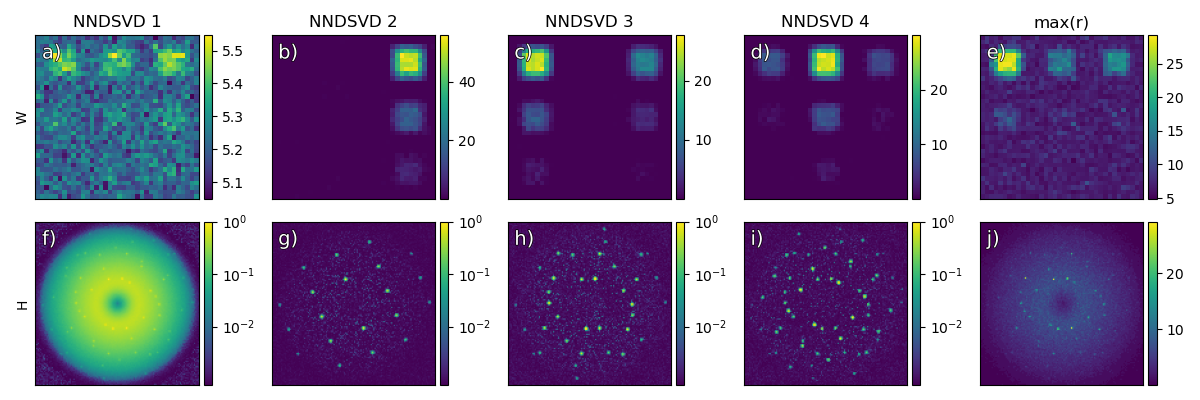

In [ ]:
# calculate nndsvd initializaiton
W_NNDSVD, H_NNDSVD = _initialize_nmf(Xf, k_NMF, init='nndsvdar', eps=1e-6, random_state=None)
scale = H_NNDSVD.max(axis=1)
H_NNDSVD /= scale[:, np.newaxis]
W_NNDSVD *= scale

# calculate residuals
WH_NNDSVD = np.dot(W_NNDSVD, H_NNDSVD)
r_NNDSVD = np.abs(Xf - WH_NNDSVD)

res_comp_NNDSVD = np.max(r_NNDSVD, axis=0).reshape((x_reci, y_reci))
res_map_NNDSVD = np.max(r_NNDSVD, axis=1).reshape((x_real, y_real))

# make graph
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(12, 4))
for i in range(k_NMF):
    im = axs[0, i].imshow(W_NNDSVD[:, i].reshape(X.shape[0], X.shape[1]))
    add_cbar(fig, axs[0, i], im)
    im = axs[1, i].imshow(H_NNDSVD[i, :].reshape(X.shape[2], X.shape[3]), norm=SymLogNorm(linthresh=1e-2)) # , norm=SymLogNorm(linthresh=1e-2)
    add_cbar(fig, axs[1, i], im)

axs[0, 0].set_ylabel('W')
axs[1, 0].set_ylabel('H')

letters = list(string.ascii_lowercase)

# residuals
im = axs[0, 4].imshow(res_map_NNDSVD)
add_cbar(fig, axs[0, 4], im)
# residuals
im = axs[1, 4].imshow(res_comp_NNDSVD) #, vmax=3
add_cbar(fig, axs[1, 4], im)

labels = ['NNDSVD 1', 'NNDSVD 2', 'NNDSVD 3', 'NNDSVD 4', 'max(r)']
for i in range(k_PCA+2):
    axs[0, i].set_title(labels[i])

for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig('figures/ZrCuAl_nndsvd.png', dpi=300)

In [ ]:
# calculate relevant losses and tolerances.
# note that these take significantly longer compared to when calculate_loss = False.

# _R is random initialization, _N is NNDSVDAR initialization, Q is QB factorization.
# random state is reset every run.
import os
import pickle

if os.path.exists('factorizations/ZrCuAl_nmf_R.pkl'):
    with open('factorizations/ZrCuAl_nmf_R.pkl', 'rb') as f:
        W_R, H_R, loss_R, tols_R = pickle.load(f)
else:
    start = time.time()
    W_R, H_R, loss_R, tols_R = nmf(Xf, k_NMF, init='random', maxiter=1000, calculate_loss=True, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     #tol=1e-10, 
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_R.pkl', 'wb') as f:
        pickle.dump((W_R, H_R, loss_R, tols_R), f)

if os.path.exists('factorizations/ZrCuAl_nmf_RQ.pkl'):
    with open('factorizations/ZrCuAl_nmf_RQ.pkl', 'rb') as f:
        W_RQ, H_RQ, loss_RQ, tols_RQ = pickle.load(f)
else:
    start = time.time()
    W_RQ, H_RQ, loss_RQ, tols_RQ = nmf(Xf, k_NMF, init='random', maxiter=1000, calculate_loss=True, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     #tol=1e-10, 
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_RQ.pkl', 'wb') as f:
        pickle.dump((W_RQ, H_RQ, loss_RQ, tols_RQ), f)

if os.path.exists('factorizations/ZrCuAl_nmf_N.pkl'):
    with open('factorizations/ZrCuAl_nmf_N.pkl', 'rb') as f:
        W_N, H_N, loss_N, tols_N = pickle.load(f)
else:
    start = time.time()
    W_N, H_N, loss_N, tols_N = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=True, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False,
                     #tol=1e-10, 
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_N.pkl', 'wb') as f:
        pickle.dump((W_N, H_N, loss_N, tols_N), f)

if os.path.exists('factorizations/ZrCuAl_nmf_NQ.pkl'):
    with open('factorizations/ZrCuAl_nmf_NQ.pkl', 'rb') as f:
        W_NQ, H_NQ, loss_NQ, tols_NQ = pickle.load(f)
else:
    start = time.time()
    W_NQ, H_NQ, loss_NQ, tols_NQ = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=True, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     #tol=1e-10, 
                     random_state=55)

    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_NQ.pkl', 'wb') as f:
        pickle.dump((W_NQ, H_NQ, loss_NQ, tols_NQ), f)

"""
1701.7289514541626
1146.2803571224213
1701.468213558197
1152.252558708191
"""

'\n1701.7289514541626\n1146.2803571224213\n1701.468213558197\n1152.252558708191\n'

In [ ]:
if os.path.exists('factorizations/ZrCuAl_nmf_N2.pkl'):
    with open('factorizations/ZrCuAl_nmf_N2.pkl', 'rb') as f:
        W_N2, H_N2 = pickle.load(f)
else:
    start = time.time()
    W_N2, H_N2 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=False, 
                     QB_project=False, oversample=20, n_subspace=2, shuffle=False, # these are not relevant here...
                     #tol=1e-10, 
                     random_state=55)

    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_N2.pkl', 'wb') as f:
        pickle.dump((W_N2, H_N2), f)

# 600.2910561561584

In [ ]:
if os.path.exists('factorizations/ZrCuAl_nmf_NQ2.pkl'):
    with open('factorizations/ZrCuAl_nmf_NQ2.pkl', 'rb') as f:
        W_NQ2, H_NQ2 = pickle.load(f)
else:
    start = time.time()
    W_NQ2, H_NQ2 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     #tol=1e-10, 
                     random_state=55)
    stop = time.time()
    print(stop - start)
    with open('factorizations/ZrCuAl_nmf_NQ2.pkl', 'wb') as f:
        pickle.dump((W_NQ2, H_NQ2), f)

# 13.204363584518433

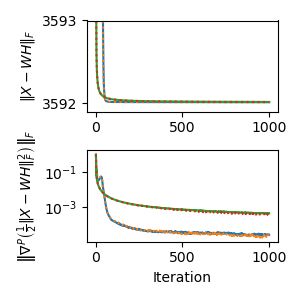

In [ ]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(3,3))
axs[0].plot(ix, loss_R)
axs[0].plot(ix, loss_RQ, ':', ms=0.5)
axs[0].plot(ix, loss_N)
axs[0].plot(ix, loss_NQ, ':', ms=0.5)
# axs[0].plot(ix, np.ones(loss_R.size) * loss_PCA, 'k:')
axs[0].set_ylim([3591.9, 3593])
axs[0].set_yticks([3592, 3593])
axs[0].set_ylabel(r'$\|X-WH\|_F$')
axs[1].plot(ix, tols_R)
axs[1].plot(ix, tols_RQ, ':', ms=0.5)
axs[1].plot(ix, tols_N, )
axs[1].plot(ix, tols_NQ, ':', ms=0.5)
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\left\| \nabla^P \left( \frac{1}{2} \|X - WH\|_F^2 \right) \right\|_F$')

plt.tight_layout()
plt.savefig("figures/ZrCuAl_evolution.png", dpi=300)

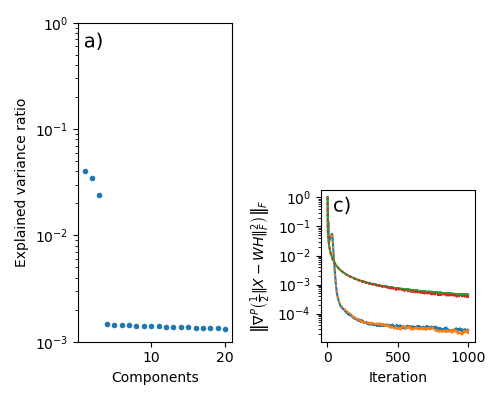

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(5, 4))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# Left panel: EVR
ax_evr = fig.add_subplot(gs[:, 0])
ax_evr.plot(np.arange(k) + 1, pca_20.explained_variance_ratio_, '.')
ax_evr.set_ylabel('Explained variance ratio')
ax_evr.set_xlabel('Components')
ax_evr.set_yscale('log')
ax_evr.set_ylim([1e-3, 1])
ax_evr.text(0.04, 0.97, letters[0] + ')', transform=ax_evr.transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

# Right panels: Evolution
ix = np.arange(loss_R.size) + 1

ax_tol = fig.add_subplot(gs[1, 1])
ax_tol.plot(ix, tols_R)
ax_tol.plot(ix, tols_RQ, ':', ms=0.5)
ax_tol.plot(ix, tols_N)
ax_tol.plot(ix, tols_NQ, ':', ms=0.5)
ax_tol.set_yscale('log')
ax_tol.set_xlabel('Iteration')
ax_tol.set_ylabel(r'$\left\| \nabla^P \left( \frac{1}{2} \|X - WH\|_F^2 \right) \right\|_F$')
ax_tol.text(0.08, 0.96, 'c)', transform=ax_tol.transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

plt.tight_layout()
plt.savefig("figures/ZrCuAl_EVR_evolution.png", dpi=300)


In [ ]:
scale = H_N2.max(axis=1)
H_N2 /= scale[:, np.newaxis]
W_N2 *= scale

# calculate residuals
WH_N2 = np.dot(W_N2, H_N2)
r_N2 = np.abs(Xf - WH_N2)

res_comp_N2 = np.max(r_N2, axis=0).reshape((x_reci, y_reci))
res_map_N2 = np.max(r_N2, axis=1).reshape((x_real, y_real))

In [ ]:
scale = H_NQ2.max(axis=1)
H_NQ2 /= scale[:, np.newaxis]
W_NQ2 *= scale

# calculate residuals
WH_NQ2 = np.dot(W_NQ2, H_NQ2)
r_NQ2 = np.abs(Xf - WH_NQ2)

res_comp_NQ2 = np.max(r_NQ2, axis=0).reshape((x_reci, y_reci))
res_map_NQ2 = np.max(r_NQ2, axis=1).reshape((x_real, y_real))

## Figures for publication

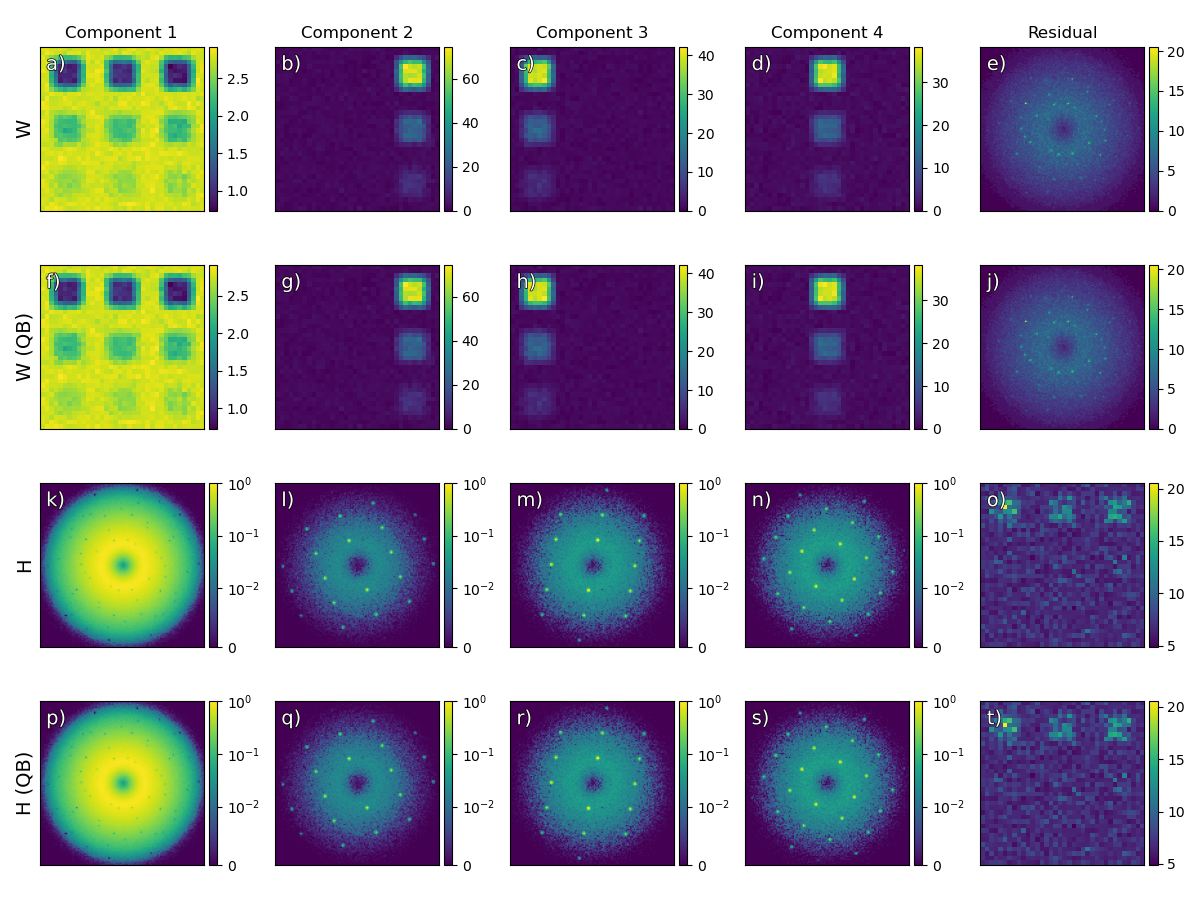

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(12, 9))

# Row 0: H noQB
for i in range(k_NMF):
    im = axs[0, i].imshow(W_N2[:, i].reshape(X.shape[0], X.shape[1])) 
    add_cbar(fig, axs[0, i], im)
im = axs[0, 4].imshow(res_comp_N2) 
add_cbar(fig, axs[0, 4], im)

# Row 1: H QB
for i in range(k_NMF):
    im = axs[1, i].imshow(W_NQ2[:, i].reshape(X.shape[0], X.shape[1])) 
    add_cbar(fig, axs[1, i], im)
im = axs[1, 4].imshow(res_comp_NQ2) 
add_cbar(fig, axs[1, 4], im)

# Row 2: W noQB
for i in range(k_NMF):
    im = axs[2, i].imshow(H_N2[i, :].reshape(X.shape[2], X.shape[3]), norm=SymLogNorm(linthresh=1e-2))
    add_cbar(fig, axs[2, i], im)
im = axs[2, 4].imshow(res_map_N2)
add_cbar(fig, axs[2, 4], im)

# Row 3: W QB
for i in range(k_NMF):
    im = axs[3, i].imshow(H_NQ2[i, :].reshape(X.shape[2], X.shape[3]), norm=SymLogNorm(linthresh=1e-2))
    add_cbar(fig, axs[3, i], im)
im = axs[3, 4].imshow(res_map_NQ2)
add_cbar(fig, axs[3, 4], im)

axs[0, 0].set_title('Component 1')
axs[0, 1].set_title('Component 2')
axs[0, 2].set_title('Component 3')
axs[0, 3].set_title('Component 4')
axs[0, 4].set_title('Residual')

font_dict = {'fontsize': 14}
axs[0, 0].set_ylabel('W', fontdict=font_dict)
axs[1, 0].set_ylabel('W (QB)', fontdict=font_dict)
axs[2, 0].set_ylabel('H', fontdict=font_dict)
axs[3, 0].set_ylabel('H (QB)', fontdict=font_dict)

for i, ax in enumerate(axs.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/ZrCuAl_combined.png", dpi=300)



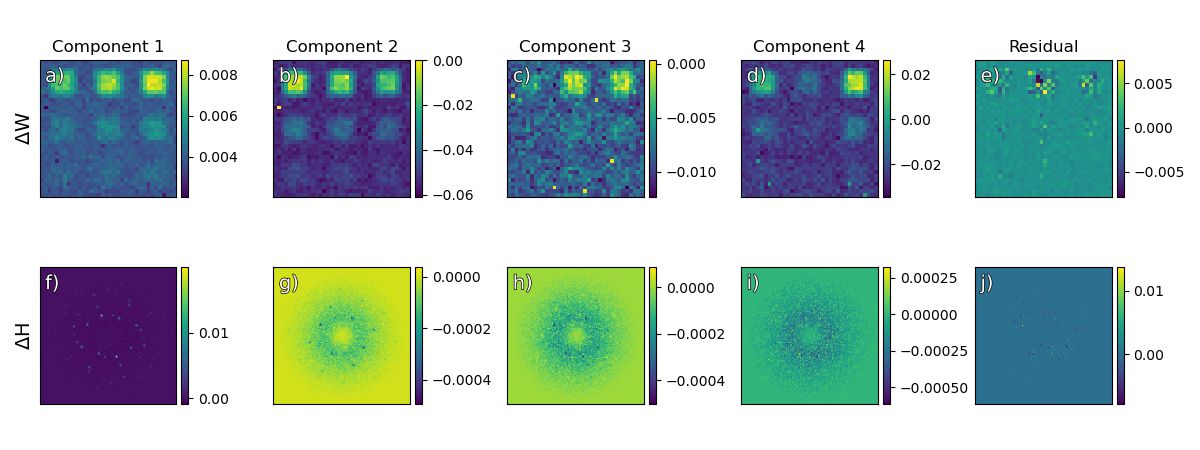

In [ ]:
# Deltas figure
fig2, axs2 = plt.subplots(nrows=2, ncols=5, figsize=(12, 4.5))

# Row 0: H diff
for i in range(k_NMF):
    im = axs2[0, i].imshow((W_N2[:, i] - W_NQ2[:, i]).reshape(X.shape[0], X.shape[1])) 
    add_cbar(fig2, axs2[0, i], im)
im = axs2[0, 4].imshow(res_map_N2 - res_map_NQ2) 
add_cbar(fig2, axs2[0, 4], im)

# Row 1: W diff
for i in range(k_NMF):
    im = axs2[1, i].imshow((H_N2[i, :] - H_NQ2[i, :]).reshape(X.shape[2], X.shape[3]))
    add_cbar(fig2, axs2[1, i], im)
im = axs2[1, 4].imshow(res_comp_N2 - res_comp_NQ2)
add_cbar(fig2, axs2[1, 4], im)

axs2[0, 0].set_title('Component 1')
axs2[0, 1].set_title('Component 2')
axs2[0, 2].set_title('Component 3')
axs2[0, 3].set_title('Component 4')
axs2[0, 4].set_title('Residual')

axs2[0, 0].set_ylabel(r'$\Delta$W', fontdict=font_dict)
axs2[1, 0].set_ylabel(r'$\Delta$H', fontdict=font_dict)

for i, ax in enumerate(axs2.ravel()):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.95, letters[i] + ')', transform=ax.transAxes, fontsize=14, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')])

plt.tight_layout()
plt.savefig("figures/ZrCuAl_deltas.png", dpi=300)

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(6, 4))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# Left panel: EVR
ax_evr = fig.add_subplot(gs[:, 0])
# We use pca_20 if it exists, else assume pca has the 20 components
pca_obj = pca_20 if 'pca_20' in locals() else pca
ax_evr.plot(np.arange(len(pca_obj.explained_variance_ratio_)) + 1, pca_obj.explained_variance_ratio_, '.')
ax_evr.set_ylabel('Explained variance ratio')
ax_evr.set_xlabel('Components')
ax_evr.set_yscale('log')
ax_evr.set_ylim([1e-3, 1])
ax_evr.set_xlim([-1,21])
ax_evr.text(0.04, 0.97, letters[0] + ')', transform=ax_evr.transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

# Right panels: Evolution
ix = np.arange(loss_R.size) + 1

ax_loss = fig.add_subplot(gs[0, 1])
l1, = ax_loss.plot(ix, loss_R, label='Random')
l2, = ax_loss.plot(ix, loss_RQ, ':', ms=0.5, label='Random + QB')
l3, = ax_loss.plot(ix, loss_N, label='NNDSVD')
l4, = ax_loss.plot(ix, loss_NQ, ':', ms=0.5, label='NNDSVD + QB')

ax_loss.set_ylabel(r'$\|X-WH\|_F$')
ax_loss.text(0.1, 0.96, 'b)', transform=ax_loss.transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
ax_loss.set_xlim([-5,500])

# Add legend to the loss panel
ax_loss.legend(fontsize=8, loc='upper right')

ax_tol = fig.add_subplot(gs[1, 1])
ax_tol.plot(ix, tols_R)
ax_tol.plot(ix, tols_RQ, ':', ms=0.5)
ax_tol.plot(ix, tols_N)
ax_tol.plot(ix, tols_NQ, ':', ms=0.5)
ax_tol.set_yscale('log')
ax_tol.set_xlabel('Iteration')
ax_tol.set_xlim([-5,500])

ax_tol.set_ylabel(r'$ \frac{\left\| \nabla^P \right\|_F} {\left\| \nabla^P \right\|_{F0}}$' ) # \left\| \nabla^P \right\|_F_0 
ax_tol.text(0.08, 0.96, 'c)', transform=ax_tol.transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

plt.tight_layout()
plt.savefig("figures/ZrCuAl_EVR_evolution.png", dpi=300)

NameError: name 'plt' is not defined